In [1]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [2]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])


Saving cyberbullying_tweets.csv to cyberbullying_tweets.csv


In [4]:
df.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [5]:
df['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
religion,7998
age,7992
gender,7973
ethnicity,7961
not_cyberbullying,7945
other_cyberbullying,7823


In [6]:
len(df)

47692

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          47692 non-null  object
 1   cyberbullying_type  47692 non-null  object
dtypes: object(2)
memory usage: 745.3+ KB


In [8]:
# Checking for null values
np.sum(df.isnull())

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
tweet_text,0
cyberbullying_type,0


In [9]:
tweet_texts, bully_type = list(df['tweet_text']), list(df['cyberbullying_type'])


In [10]:
df.iloc[0][0]

/tmp/ipython-input-2900375399.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.iloc[0][0]


'In other words #katandandre, your food was crapilicious! #mkr'

In [11]:
# Encoding the labels
from sklearn.preprocessing import LabelEncoder

labelencoder = LabelEncoder()

df['cyberbullying_type_encoded'] = labelencoder.fit_transform(df['cyberbullying_type'])

In [12]:
df[['cyberbullying_type', 'cyberbullying_type_encoded']].value_counts()

,,count
cyberbullying_type,cyberbullying_type_encoded,
religion,5,7998
age,0,7992
gender,2,7973
ethnicity,1,7961
not_cyberbullying,3,7945
other_cyberbullying,4,7823


In [13]:
# converting tweet text to lower case
df['tweet_text'] = df['tweet_text'].str.lower()
df.tail()

,tweet_text,cyberbullying_type,cyberbullying_type_encoded
47687,"black ppl aren't expected to do anything, depe...",ethnicity,1
47688,turner did not withhold his disappointment. tu...,ethnicity,1
47689,i swear to god. this dumb nigger bitch. i have...,ethnicity,1
47690,yea fuck you rt @therealexel: if youre a nigge...,ethnicity,1
47691,bro. u gotta chill rt @chillshrammy: dog fuck ...,ethnicity,1


In [14]:
# stopwords list that needs to be excluded from the data
stopwordlist = ['a', 'about', 'above', 'after', 'again', 'ain', 'all', 'am', 'an',
             'and','any','are', 'as', 'at', 'be', 'because', 'been', 'before',
             'being', 'below', 'between','both', 'by', 'can', 'd', 'did', 'do',
             'does', 'doing', 'down', 'during', 'each','few', 'for', 'from',
             'further', 'had', 'has', 'have', 'having', 'he', 'her', 'here',
             'hers', 'herself', 'him', 'himself', 'his', 'how', 'i', 'if', 'in',
             'into','is', 'it', 'its', 'itself', 'just', 'll', 'm', 'ma',
             'me', 'more', 'most','my', 'myself', 'now', 'o', 'of', 'on', 'once',
             'only', 'or', 'other', 'our', 'ours','ourselves', 'out', 'own', 're',
             's', 'same', 'she', "shes", 'should', "shouldve",'so', 'some', 'such',
             't', 'than', 'that', "thatll", 'the', 'their', 'theirs', 'them',
             'themselves', 'then', 'there', 'these', 'they', 'this', 'those',
             'through', 'to', 'too','under', 'until', 'up', 've', 'very', 'was',
             'we', 'were', 'what', 'when', 'where','which','while', 'who', 'whom',
             'why', 'will', 'with', 'won', 'y', 'you', "youd","youll", "youre",
             "youve", 'your', 'yours', 'yourself', 'yourselves']

In [15]:
# removing stopwoords from the tweet text
STOPWORDS = set(stopwordlist)

def clean_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

df['tweet_text'] = df['tweet_text'].apply(lambda text: clean_stopwords(text))# cleaning and removing punctuations

import string
english_puctuations = string.punctuation

def clean_puctuations(text):
    translator = str.maketrans('','', english_puctuations)
    return text.translate(translator)

df['tweet_text'] = df['tweet_text'].apply(lambda x : clean_puctuations(x))


In [16]:
df['tweet_text'][20]

'halalcunty biebervalue liamxkiwi greenlinerzjm halalflaws know saudis chased girls burning building httptco8b1aclczn9'

In [17]:
# cleaning and removing repeating characters

def clean_repeating_characters(text):
    return re.sub(r'(.)1+', r'1', text)

df['tweet_text'] = df['tweet_text'].apply(lambda x: clean_repeating_characters(x))

In [18]:
df['tweet_text'][55]

'bullshit mkr mkr215'

In [19]:
# cleaning and removing URLs

def clean_URLs(text):
    return re.sub(r"((www.[^s]+)|(http\S+))","",text)

df['tweet_text'] = df['tweet_text'].apply(lambda x : clean_URLs(x))

In [20]:
df['tweet_text'][280]

'andaasonsan '

In [21]:
# cleaning and removing numeric data

def clean_numeric(text):
    return re.sub('[0-9]+', '', text)

df['tweet_text'] = df['tweet_text'].apply(lambda x: clean_numeric(x))

In [22]:
df['tweet_text'][223]

'fact  cute boys world  go school sick shit'

In [23]:
from nltk.tokenize import RegexpTokenizer

tokenizer = RegexpTokenizer(r'\w+')
df['tweet_text'] = df['tweet_text'].apply(tokenizer.tokenize)



In [24]:
df['tweet_text'][24]

['wishing',
 'arena',
 'partner',
 'on',
 'gtgt',
 'really',
 'want',
 'get',
 'pvp',
 'happening']

In [25]:
# stemming

import nltk

st = nltk.PorterStemmer()

def text_stemming(text):
    text = [st.stem(word) for word in text]
    return text

df['tweet_text'] = df['tweet_text'].apply(lambda x: text_stemming(x))

In [26]:
df['tweet_text'][35]

['andythewooki',
 'what',
 'quot',
 'jack',
 'off',
 'one',
 'hand',
 'point',
 'other']

In [27]:
df['tweet_text'].head()

,tweet_text
0,"[word, katandandr, food, crapilici, mkr]"
1,"[aussietv, white, mkr, theblock, imacelebritya..."
2,"[xochitlsuckkk, classi, whore, red, velvet, cu..."
3,"[jasongio, meh, p, thank, head, up, but, not, ..."
4,"[rudhoeenglish, isi, account, pretend, kurdish..."


In [28]:
df[['cyberbullying_type', 'cyberbullying_type_encoded']].value_counts()


,,count
cyberbullying_type,cyberbullying_type_encoded,
religion,5,7998
age,0,7992
gender,2,7973
ethnicity,1,7961
not_cyberbullying,3,7945
other_cyberbullying,4,7823



### **Data preprocessing steps**


### **Step 1: Data Loading and Initial Inspection**

The cyberbullying tweets dataset was loaded into a Pandas DataFrame. Initial inspection was performed by viewing sample records, checking dataset dimensions, analyzing the distribution of cyberbullying categories, and verifying the absence of missing values.



### **Step 2: Label Encoding**

The categorical target variable (`cyberbullying_type`) was converted into numerical form using label encoding. This transformation is necessary because machine learning algorithms require numerical labels for training.



### **Step 3: Text Normalization**

All tweet text was converted to lowercase to ensure consistency and avoid treating the same words with different cases as separate terms.



### **Step 4: Noise Removal**

Common English stopwords, punctuation marks, URLs, numeric characters, and repeated character sequences were removed from the tweets. This step reduced irrelevant information and standardized informal social media text.



### **Step 5: Tokenization**

Each cleaned tweet was split into individual words (tokens) using a regular expression-based tokenizer. Tokenization allows text to be processed at the word level.



### **Step 6: Stemming**

Stemming was applied to reduce words to their root form. This helped minimize vocabulary size and group morphologically similar words together.



### **Step 7: Text Reconstruction**

The processed tokens were joined back into single text strings to enable statistical analysis and vectorization. Empty tweets generated during preprocessing were replaced with a placeholder value.



### **Step 8: Feature Relevance Analysis**

A chi-square statistical test was conducted on the preprocessed data to examine the association between extracted textual features and cyberbullying categories.



### **Step 9: Feature Extraction using TF-IDF**

The cleaned tweet text was transformed into numerical feature vectors using TF-IDF vectorization. The vectorizer was fitted on the training data to learn term importance and applied to both training and testing datasets.



### **Step 10: Model Training and Evaluation**

The vectorized data was used to train supervised machine learning models. Model performance was evaluated using appropriate classification metrics.




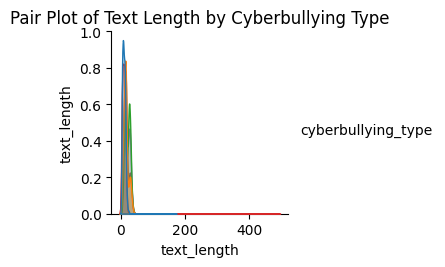

In [29]:
# Pair plot for text length and cyberbullying type
df['text_length'] = df['tweet_text'].apply(len)
sns.pairplot(data=df, hue="cyberbullying_type", vars=["text_length"])
plt.title("Pair Plot of Text Length by Cyberbullying Type")
plt.show()

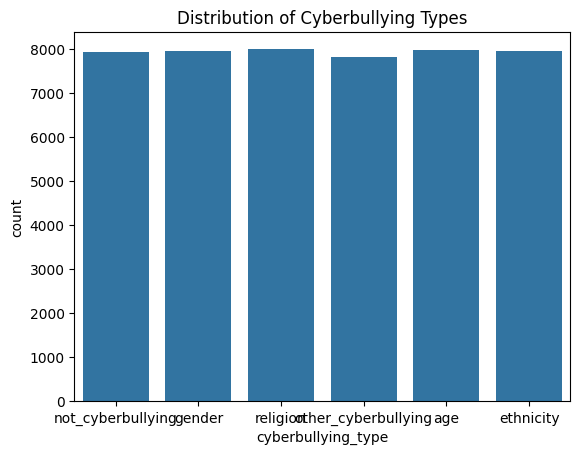

In [30]:
# Visualize the distribution of the "cyberbullying_type" column
sns.countplot(data=df, x="cyberbullying_type")
plt.title("Distribution of Cyberbullying Types")
plt.show()

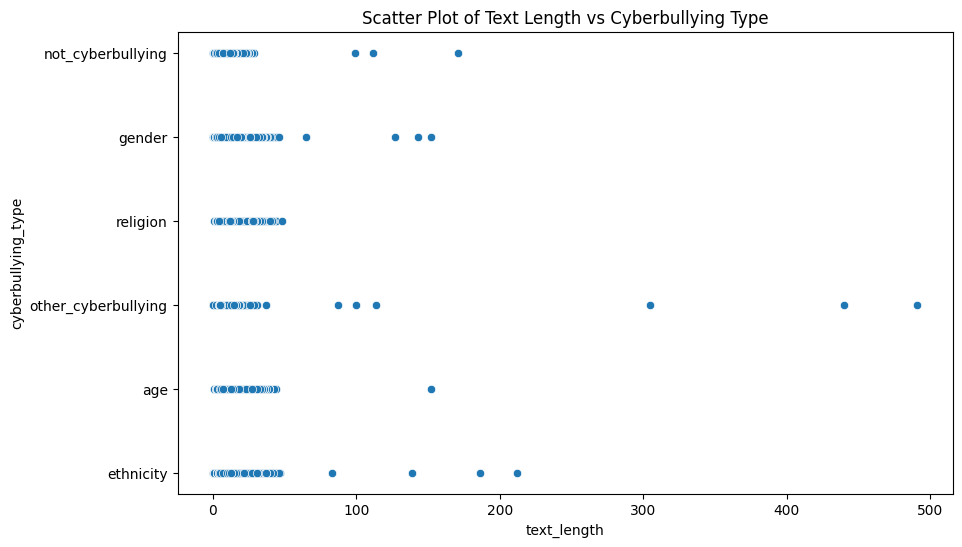

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# The dataframe 'df' is already loaded and 'text_length' calculated in previous steps.
# This cell will now only focus on generating the scatter plot.

# Set a larger figure size
plt.figure(figsize=(10, 6))

# Create a scatter plot
sns.scatterplot(data=df, x="text_length", y="cyberbullying_type")
plt.title("Scatter Plot of Text Length vs Cyberbullying Type")

# Show the plot
plt.show()

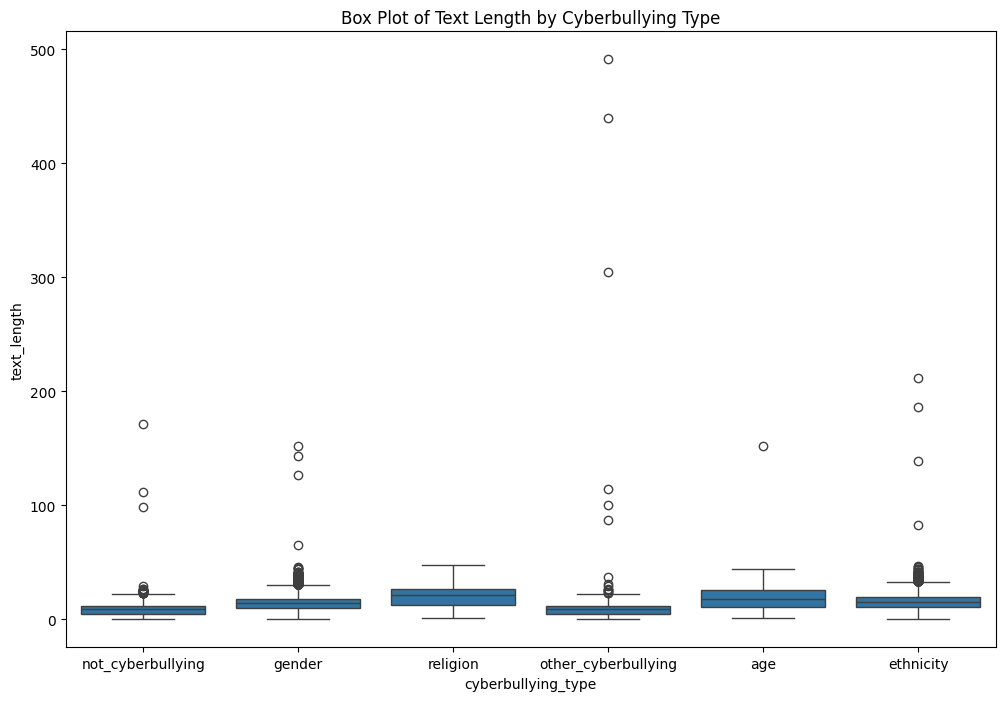

In [32]:
# Set a larger figure size and create a centralized box plot
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x="cyberbullying_type", y="text_length")
plt.title("Box Plot of Text Length by Cyberbullying Type")

# Show the plot
plt.show()

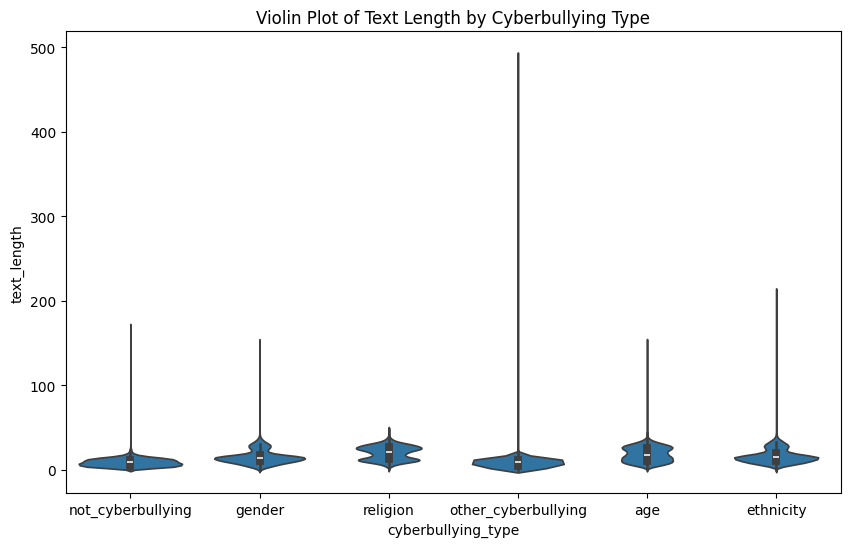

In [33]:
# Calculate the text length and add it as a new column
df['text_length'] = df['tweet_text'].apply(len)

# Set a larger figure size for the violin plot
plt.figure(figsize=(10, 6))

# Create a violin plot
sns.violinplot(data=df, x="cyberbullying_type", y="text_length")
plt.title("Violin Plot of Text Length by Cyberbullying Type")

# Show the plot
plt.show()

In [34]:
from scipy.stats import chi2_contingency
import pandas as pd

# Join the list of words in 'tweet_text' back into a single string
df['tweet_text_joined'] = df['tweet_text'].apply(lambda x: ' '.join(x))

# Create a contingency table
# Use the newly created 'tweet_text_joined' column
contingency_table = pd.crosstab(df['tweet_text_joined'], df['cyberbullying_type'])

# Perform the chi-squared test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results
print("Chi-squared statistic:", chi2)
print("P-value:", p)
print("Degrees of freedom:", dof)
print("Expected frequencies table:")
print(expected)


Chi-squared statistic: 228152.3506078005
P-value: 0.0676731239093451
Degrees of freedom: 227145
Expected frequencies table:
[[18.93600604 18.86255556 18.89098801 18.82464564 18.53558249 18.95022226]
 [ 0.16757527  0.16692527  0.16717689  0.16658978  0.1640317   0.16770108]
 [ 0.16757527  0.16692527  0.16717689  0.16658978  0.1640317   0.16770108]
 ...
 [ 0.16757527  0.16692527  0.16717689  0.16658978  0.1640317   0.16770108]
 [ 0.16757527  0.16692527  0.16717689  0.16658978  0.1640317   0.16770108]
 [ 0.16757527  0.16692527  0.16717689  0.16658978  0.1640317   0.16770108]]


In [37]:
all_words = []
for text in new_df:
    all_words.extend(text.split())

print(f"Total number of words: {len(all_words)}")

Total number of words: 563911


In [38]:
import nltk
freq_dist = nltk.FreqDist(all_words)

print("Frequency distribution calculated.")

Frequency distribution calculated.


In [39]:
top_words = freq_dist.most_common(20)

print("Top 20 most frequent words extracted.")

Top 20 most frequent words extracted.


In [40]:
import pandas as pd

top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

print("DataFrame for top words created.")

DataFrame for top words created.


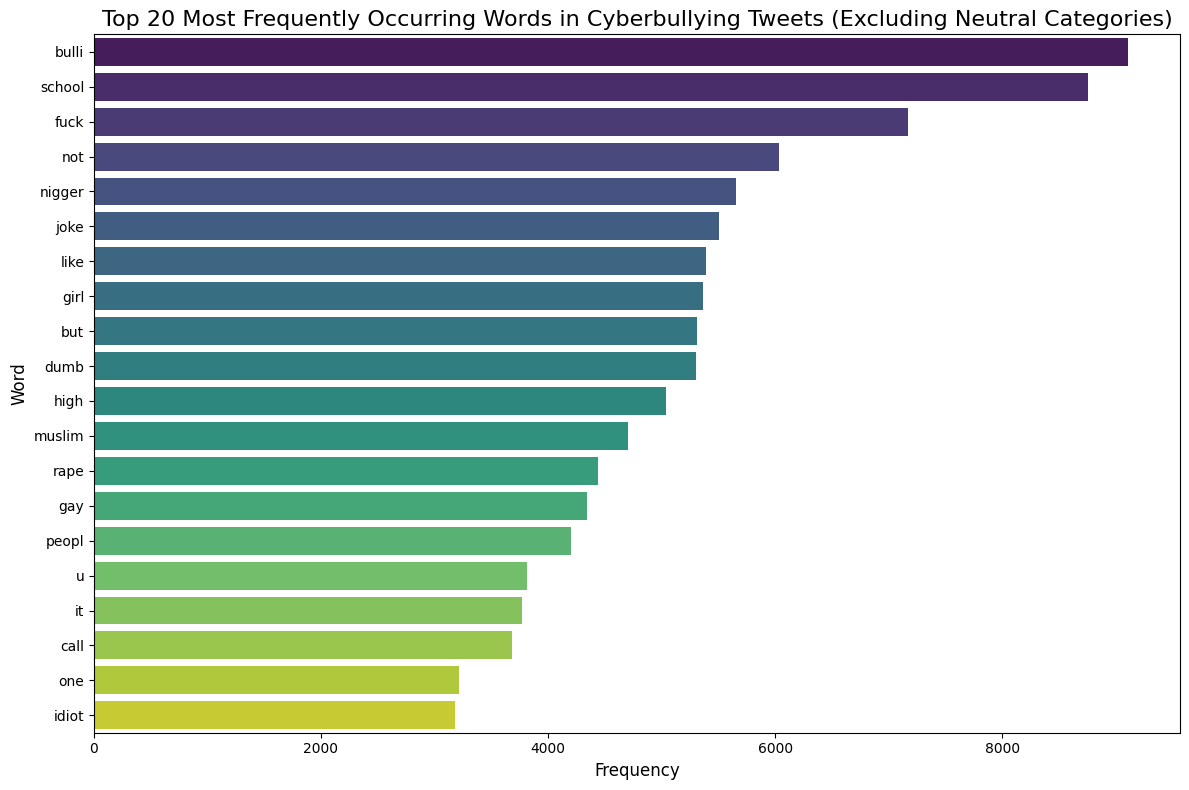

Bar chart of top 20 words displayed.


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for better readability
plt.figure(figsize=(12, 8))

# Create the bar plot, addressing the FutureWarning
sns.barplot(x='Frequency', y='Word', data=top_words_df, palette='viridis', hue='Word', legend=False)

# Add title and labels
plt.title('Top 20 Most Frequently Occurring Words in Cyberbullying Tweets (Excluding Neutral Categories)', fontsize=16)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Word', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

print("Bar chart of top 20 words displayed.")


* The word **“bulli”** appears most frequently, confirming the core focus of the dataset on cyberbullying behavior.
* Offensive terms such as **“fuck”**, **“nigger”**, **“dumb”**, **“rape”**, and **“idiot”** highlight the aggressive and abusive nature of the content.
* Words like **“girl”**, **“muslim”**, and **“gay”** indicate common targets of cyberbullying based on identity or demographics.
* The presence of **“school”** and **“high”** suggests that educational environments are common contexts for cyberbullying.
* Terms such as **“joke”** and **“call”** imply that bullying is sometimes masked as humor or occurs through name-calling.
* These recurring words reveal strong linguistic patterns useful for building effective cyberbullying detection models.



In [48]:
# plotting word cloud excluding other_cybberbullying and not_cyberbullying
new_df = df
new_df = new_df[new_df['cyberbullying_type'] != 'other_cyberbullying']
new_df = new_df[new_df['cyberbullying_type'] != 'not_cyberbullying']
new_df = new_df['tweet_text'].apply(lambda x: " ".join(x))

In [49]:
new_df

,tweet_text
7945,rape realzvasiyana nema joke drunk gay lesbian...
7946,never saw celebr say anyth like obama b maher ...
7947,manhattaknight mean he gay but use gender slur...
7948,rt raulnovo aliciabernardez alexaim mecaesm fe...
7949,rape rape fact read one post guy get rape comm...
...,...
47687,black ppl arent expect anyth depend anyth yet ...
47688,turner not withhold disappoint turner call cou...
47689,swear god dumb nigger bitch got bleach hair re...
47690,yea fuck rt therealexel nigger fuck unfollow m...


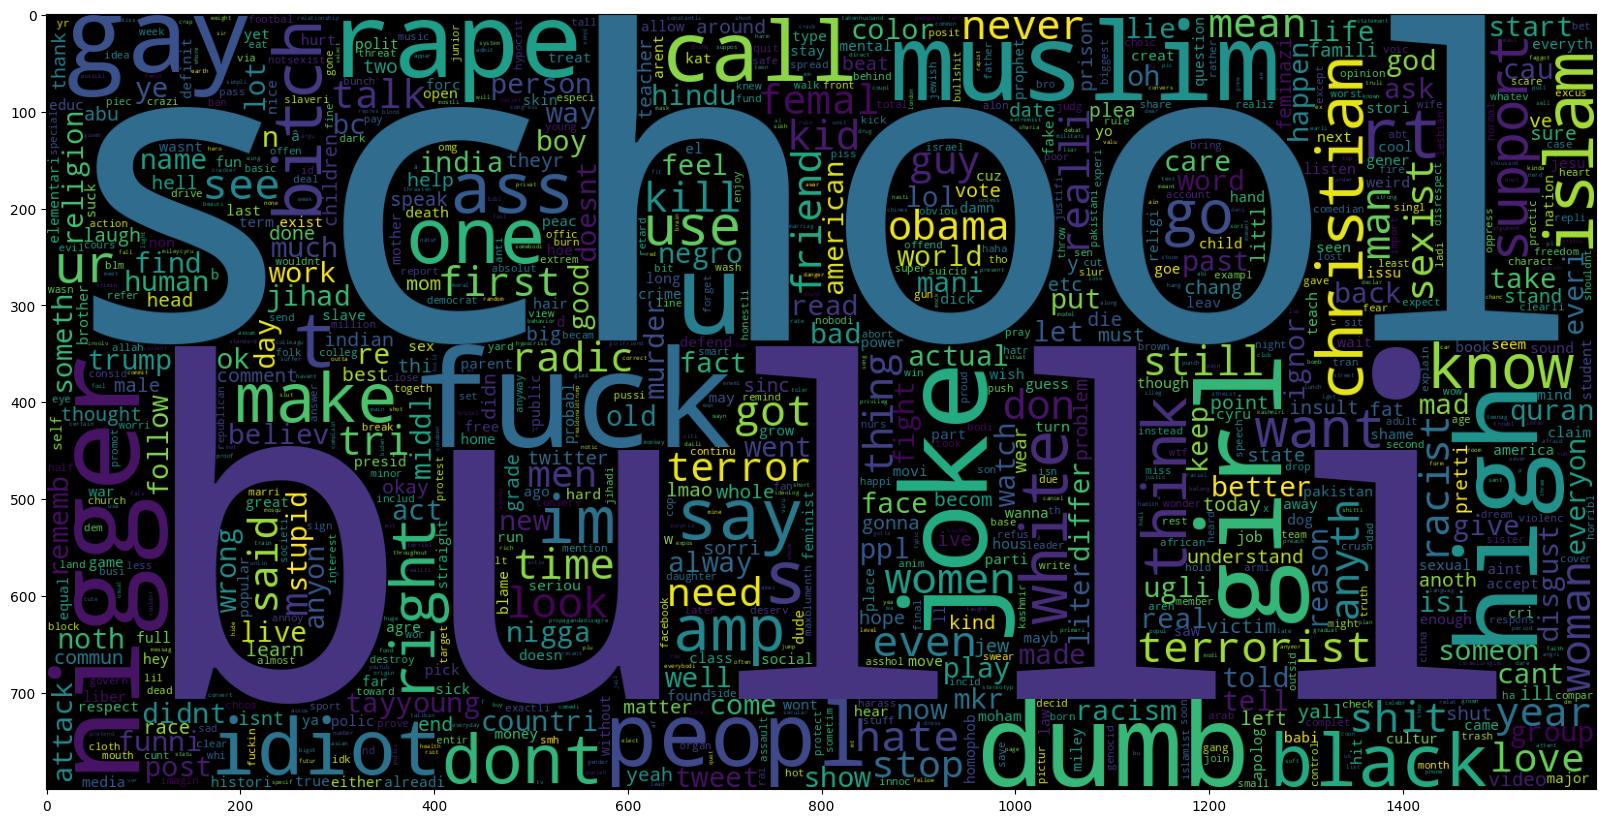

In [50]:
plt.figure(figsize= (20,20))
wc = WordCloud(max_words=1000, width= 1600, height= 800,
                collocations= False).generate(' '.join(new_df))
plt.imshow(wc)

In [44]:
# Creating a word cloud
# We will have to exclude the tweets which are not_cyberbullying for this task
from google.colab import files
uploaded = files.upload()
data = pd.read_csv(list(uploaded.keys())[0])

data = data[data['cyberbullying_type'] != "not_cyberbullying"]
data['cyberbullying_type'].value_counts()

Saving cyberbullying_tweets.csv to cyberbullying_tweets (1).csv


,count
cyberbullying_type,
religion,7998
age,7992
gender,7973
ethnicity,7961
other_cyberbullying,7823


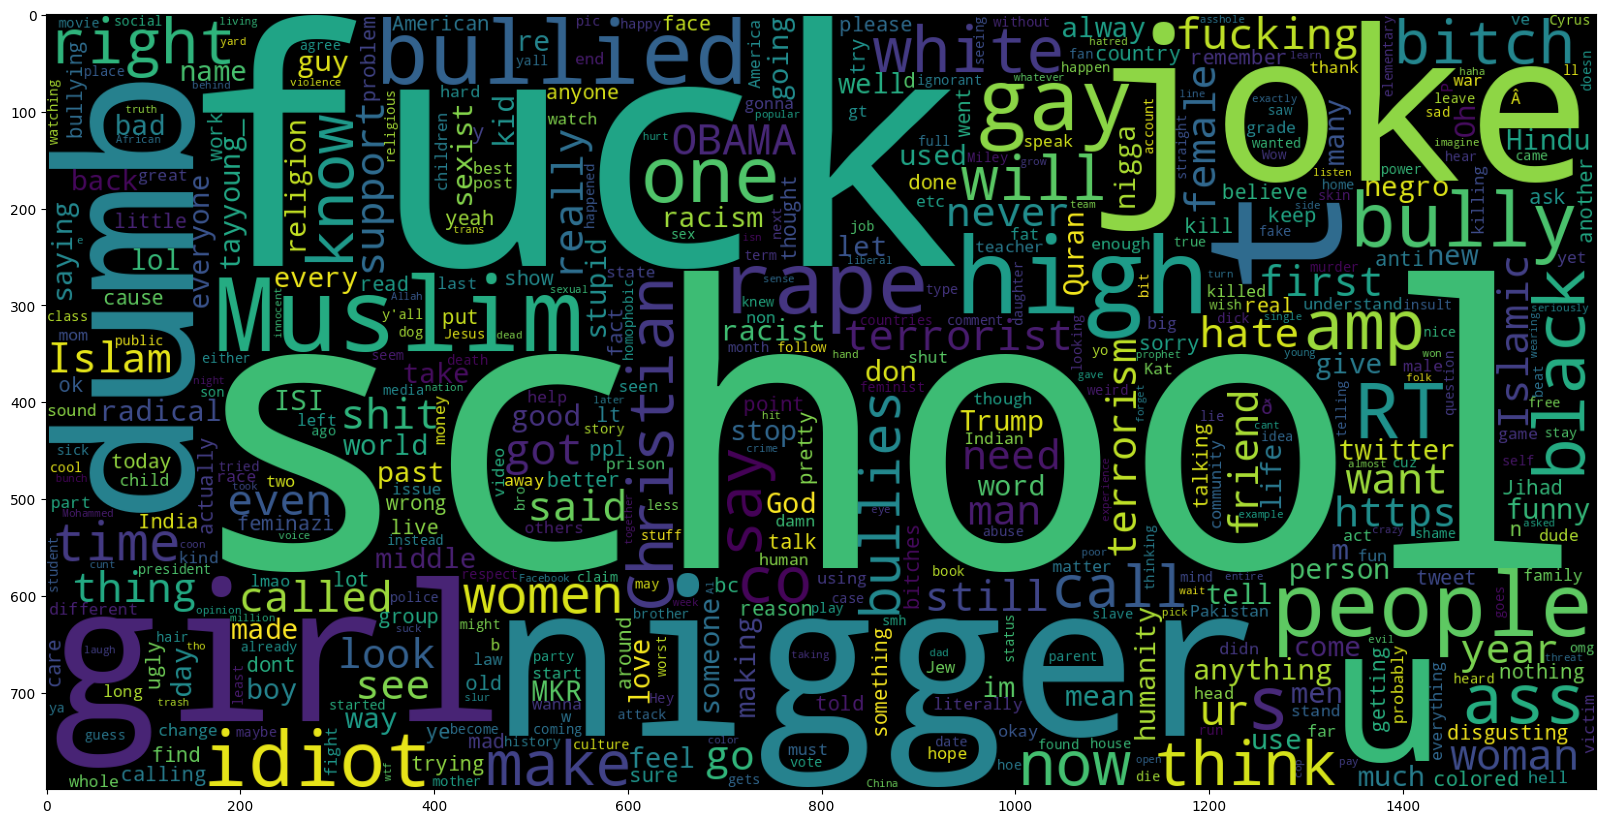

In [45]:
# word cloud

plotting_data = data['tweet_text']
plt.figure(figsize= (20,20))
wc = WordCloud(max_words=500, width= 1600, height= 800,
                collocations= False).generate(' '.join(plotting_data))
plt.imshow(wc)

In [46]:
# excluding the other_cyberbullying values and plotting again
data_2 = data[data['cyberbullying_type'] != "not_cyberbullying"]
data_2 = data[data['cyberbullying_type'] != "other_cyberbullying"]
data_2['cyberbullying_type'].value_counts()

,count
cyberbullying_type,
religion,7998
age,7992
gender,7973
ethnicity,7961


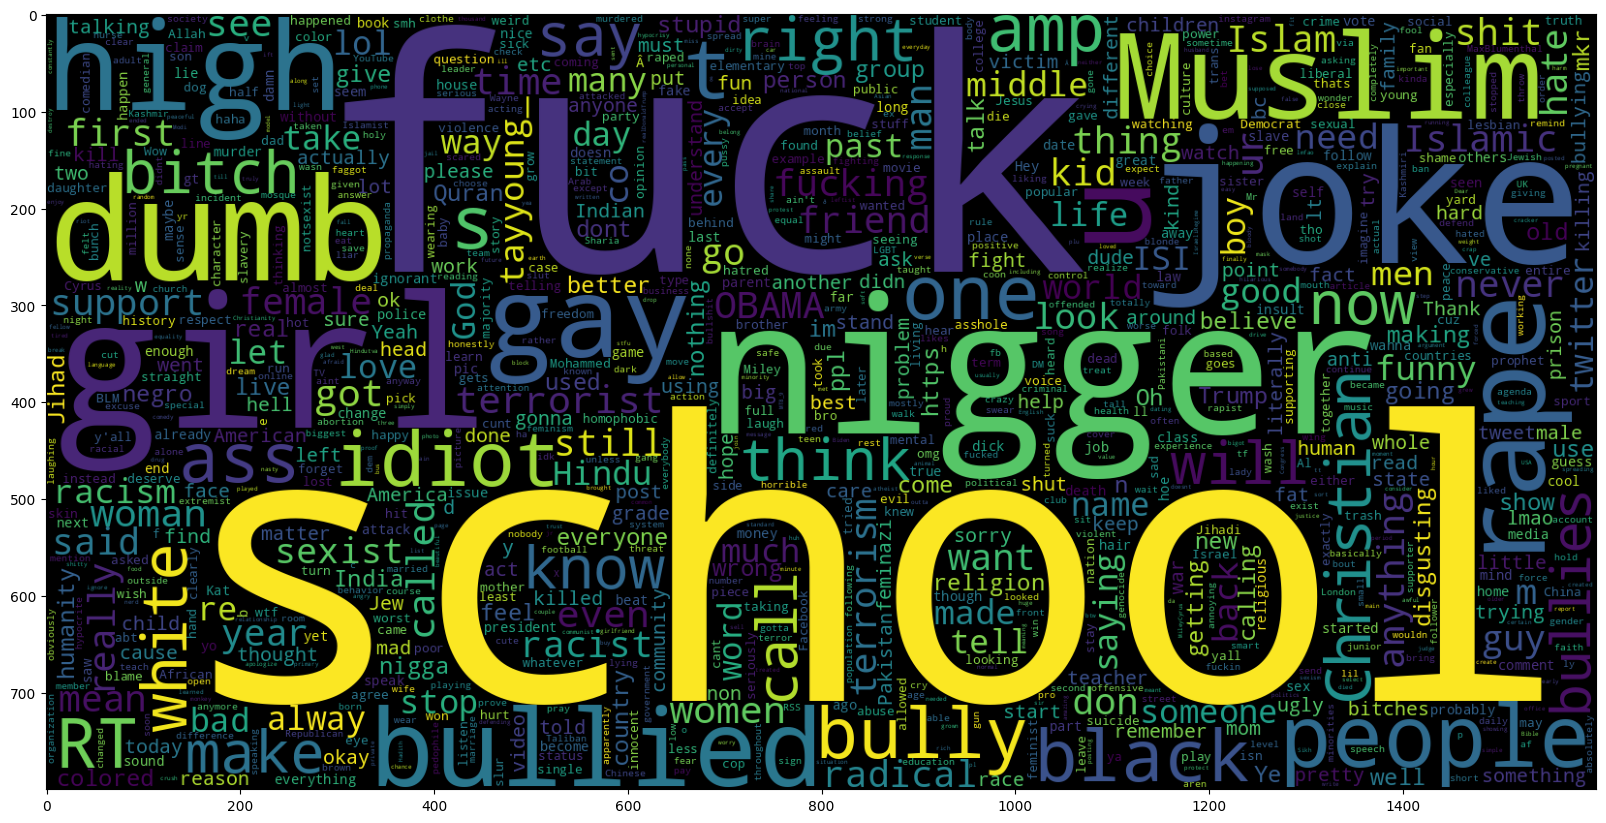

In [47]:
plotting_data = data_2['tweet_text']
plt.figure(figsize= (20,20))
wc = WordCloud(max_words=1000, width= 1600, height= 800,
                collocations= False).generate(' '.join(plotting_data))
plt.imshow(wc)



## **Visualization Analysis and Insights**

### **1. Distribution of Cyberbullying Types**

This count plot shows the frequency of each cyberbullying category. The dataset is well balanced across all six classes, which helps prevent bias during model training and ensures fair learning across categories.



### **2. Text Length Distribution by Cyberbullying Type**

Pair plots and scatter plots comparing text length across categories show heavy overlap among all classes. This indicates that tweet length alone is not a strong feature for distinguishing cyberbullying types.



### **3. Statistical View of Text Length**

Box plots and violin plots further confirm that the median text length and overall distribution are very similar across all cyberbullying categories. This reinforces that text length is not a reliable standalone indicator.



### **4. Most Frequent Words in Cyberbullying Tweets**

The bar chart of the top 20 most frequent words highlights commonly used offensive and discriminatory terms. The dominance of abusive words and references to specific groups (e.g., gender, religion, ethnicity) reflects the aggressive and targeted nature of cyberbullying content.



### **5. Word Cloud Analysis**

Word clouds provide a visual summary of dominant terms across different cyberbullying subsets. Across all variations, offensive language and references to common targets appear consistently, confirming recurring patterns in cyberbullying text.



### **Overall Observation**

The visualizations show that while tweet length is not a strong discriminative feature, the **content and vocabulary of the text** play a crucial role in identifying cyberbullying. These insights support the use of text-based feature extraction methods such as TF-IDF for effective classification.




In [51]:
df

,tweet_text,cyberbullying_type,cyberbullying_type_encoded,text_length,tweet_text_joined
0,"[word, katandandr, food, crapilici, mkr]",not_cyberbullying,3,5,word katandandr food crapilici mkr
1,"[aussietv, white, mkr, theblock, imacelebritya...",not_cyberbullying,3,11,aussietv white mkr theblock imacelebrityau tod...
2,"[xochitlsuckkk, classi, whore, red, velvet, cu...",not_cyberbullying,3,6,xochitlsuckkk classi whore red velvet cupcak
3,"[jasongio, meh, p, thank, head, up, but, not, ...",not_cyberbullying,3,13,jasongio meh p thank head up but not concern a...
4,"[rudhoeenglish, isi, account, pretend, kurdish...",not_cyberbullying,3,9,rudhoeenglish isi account pretend kurdish acco...
...,...,...,...,...,...
47687,"[black, ppl, arent, expect, anyth, depend, any...",ethnicity,1,22,black ppl arent expect anyth depend anyth yet ...
47688,"[turner, not, withhold, disappoint, turner, ca...",ethnicity,1,31,turner not withhold disappoint turner call cou...
47689,"[swear, god, dumb, nigger, bitch, got, bleach,...",ethnicity,1,13,swear god dumb nigger bitch got bleach hair re...
47690,"[yea, fuck, rt, therealexel, nigger, fuck, unf...",ethnicity,1,11,yea fuck rt therealexel nigger fuck unfollow m...


In [52]:
df['tweet_text'] = df['tweet_text'].apply(lambda x : " ".join(x))
df

,tweet_text,cyberbullying_type,cyberbullying_type_encoded,text_length,tweet_text_joined
0,word katandandr food crapilici mkr,not_cyberbullying,3,5,word katandandr food crapilici mkr
1,aussietv white mkr theblock imacelebrityau tod...,not_cyberbullying,3,11,aussietv white mkr theblock imacelebrityau tod...
2,xochitlsuckkk classi whore red velvet cupcak,not_cyberbullying,3,6,xochitlsuckkk classi whore red velvet cupcak
3,jasongio meh p thank head up but not concern a...,not_cyberbullying,3,13,jasongio meh p thank head up but not concern a...
4,rudhoeenglish isi account pretend kurdish acco...,not_cyberbullying,3,9,rudhoeenglish isi account pretend kurdish acco...
...,...,...,...,...,...
47687,black ppl arent expect anyth depend anyth yet ...,ethnicity,1,22,black ppl arent expect anyth depend anyth yet ...
47688,turner not withhold disappoint turner call cou...,ethnicity,1,31,turner not withhold disappoint turner call cou...
47689,swear god dumb nigger bitch got bleach hair re...,ethnicity,1,13,swear god dumb nigger bitch got bleach hair re...
47690,yea fuck rt therealexel nigger fuck unfollow m...,ethnicity,1,11,yea fuck rt therealexel nigger fuck unfollow m...


In [53]:
# Splitting the data into train and test
X, y = df['tweet_text'], df['cyberbullying_type_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 41)

In [54]:
df[['cyberbullying_type', 'cyberbullying_type_encoded']].value_counts()

,,count
cyberbullying_type,cyberbullying_type_encoded,
religion,5,7998
age,0,7992
gender,2,7973
ethnicity,1,7961
not_cyberbullying,3,7945
other_cyberbullying,4,7823


In [55]:
df['tweet_text'] = df['tweet_text'].apply(lambda x: 'placeholder' if len(x) == 0 else x)

In [56]:
X_train

,tweet_text
10035,anoth fellow gay pleas don t compar revers hig...
14737,sinc hard new norm femal still act shi don t n...
1209,thanksgiv drink game classic half tabl no idea...
12259,friday morn workplac joke move gay joke rape j...
45672,mattscorpio ya nigga bf dump huh tough break r...
...,...
31597,peerwork uh one group liter kill peopl nut
41281,racism real world declin must live fuck matrix...
20450,but isi quran noraml muslim quran same but say...
931,nickdwilliam know putin would spend second loo...


In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use the 'english' stop words from scikit-learn
vectoriser = TfidfVectorizer(ngram_range=(1,2), max_features= 50000, stop_words='english')

vectoriser.fit(X_train)
print("No. of feature words: ",len(vectoriser.get_feature_names_out()))

No. of feature words:  50000


In [58]:
# transforming the data
X_train = vectoriser.transform(X_train)
X_test = vectoriser.transform(X_test)

In [59]:
from sklearn.svm import LinearSVC

# Model
# Using LinearSVC for faster training on large, sparse datasets
svm_model_linear = LinearSVC(C=1, random_state=42, dual=False).fit(X_train, y_train)
svm_predictions  = svm_model_linear.predict(X_test)
accuracy = svm_model_linear.score(X_test, y_test)
print(accuracy)


0.8255521386636846


## Random Forest Classifier

We will now train a Random Forest classifier, which is an ensemble learning method suitable for classification tasks. It works by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) of the individual trees. This approach generally improves predictive accuracy and controls over-fitting.

We will then evaluate its performance using accuracy and a classification report.

In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest Classifier
# n_estimators: The number of trees in the forest.
# random_state: Controls the randomness of the bootstrapping of the samples used when building trees and the sampling of the features to consider when looking for the best split.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors

# Train the model
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")

# Print classification report for more detailed metrics
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_predictions))

Training Random Forest model...
Random Forest model trained.

Random Forest Accuracy: 0.8246

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2356
           1       0.98      0.98      0.98      2466
           2       0.90      0.84      0.87      2393
           3       0.59      0.51      0.55      2402
           4       0.57      0.67      0.62      2358
           5       0.96      0.97      0.96      2333

    accuracy                           0.82     14308
   macro avg       0.83      0.82      0.82     14308
weighted avg       0.83      0.82      0.82     14308



## Confusion Matrix for Random Forest Classifier

Let's visualize the confusion matrix for the Random Forest model to see its performance per class.

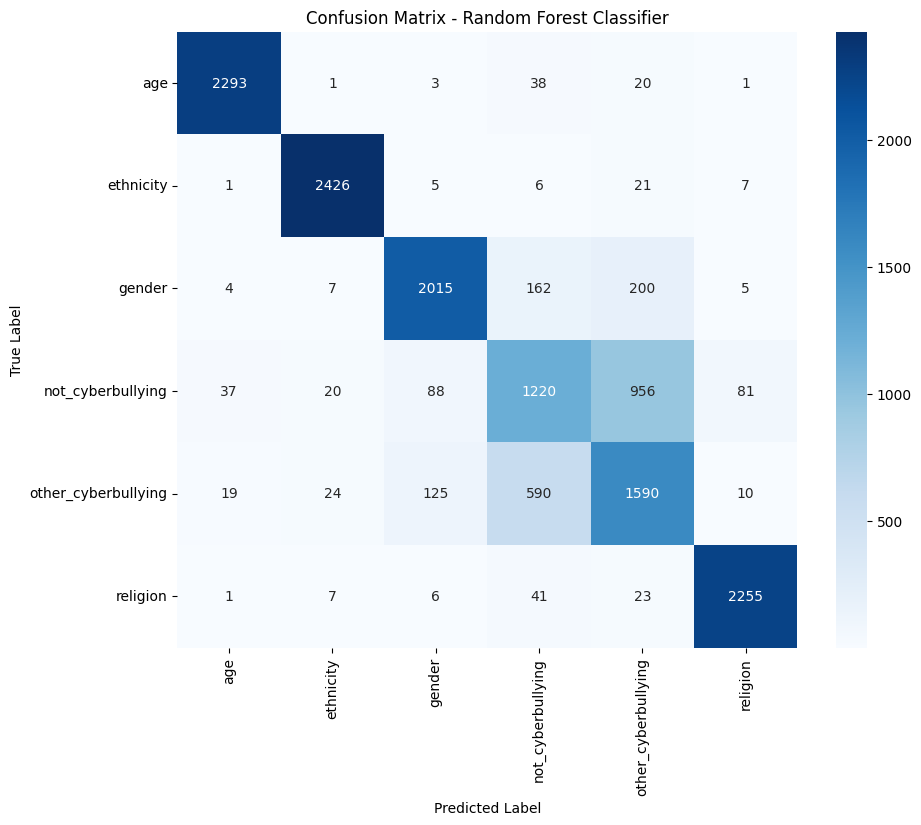

In [61]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, rf_predictions)

# Get class labels from the original LabelEncoder
# Assuming labelencoder from cell -372_IIk4bjW is still available
class_labels = labelencoder.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Confusion Matrix for LinearSVC

Now, let's visualize the confusion matrix for the LinearSVC model to compare its per-class performance with Random Forest.

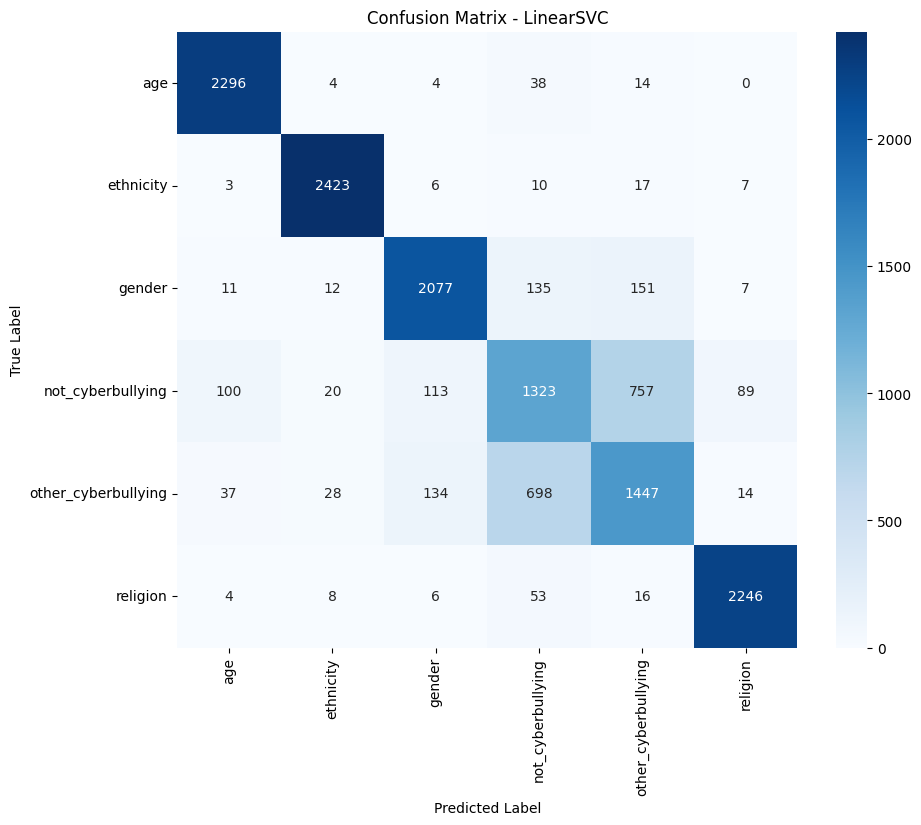

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix for LinearSVC
cm_svm = confusion_matrix(y_test, svm_predictions)

# Get class labels from the original LabelEncoder
# Assuming labelencoder from cell -372_IIk4bjW is still available
class_labels = labelencoder.classes_

plt.figure(figsize=(10, 8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - LinearSVC')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Example Prediction for a New Tweet

Let's test our Random Forest model with a new tweet. We need to apply all the preprocessing steps to the new text, vectorize it, and then use the `predict` method.

In [63]:
# Define a new sample tweet
new_tweet = "Blaming Muslims for every problem is pure ignorance. This hateful mindset is disgusting, lazy, and shows how little you actually understand the world"

print(f"Original new tweet: {new_tweet}\n")

# --- Apply the same preprocessing steps as done for the training data ---

# 1. Lowercasing
processed_tweet = new_tweet.lower()

# 2. Stopword Removal
STOPWORDS = set(stopwordlist) # Ensure stopwordlist is defined from earlier
processed_tweet = " ".join([word for word in processed_tweet.split() if word not in STOPWORDS])

# 3. Punctuation Removal
import string
english_puctuations = string.punctuation
translator = str.maketrans('', '', english_puctuations)
processed_tweet = processed_tweet.translate(translator)

# 4. Repeating Characters Removal (using the function from earlier)
def clean_repeating_characters(text):
    return re.sub(r'(.)1+', r'1', text)
processed_tweet = clean_repeating_characters(processed_tweet)

# 5. URL Removal (using the function from earlier)
def clean_URLs(text):
    return re.sub(r"((www.[^s]+)|(http\S+))","",text)
processed_tweet = clean_URLs(processed_tweet)

# 6. Numeric Data Removal (using the function from earlier)
def clean_numeric(text):
    return re.sub('[0-9]+', '', text)
processed_tweet = clean_numeric(processed_tweet)

# 7. Tokenization
from nltk.tokenize import RegexpTokenizer
tokenizer = RegexpTokenizer(r'\w+')
processed_tweet_tokens = tokenizer.tokenize(processed_tweet)

# 8. Stemming
import nltk
st = nltk.PorterStemmer()
processed_tweet_stemmed = [st.stem(word) for word in processed_tweet_tokens]

# 9. Join tokens back into a single string
final_processed_tweet = " ".join(processed_tweet_stemmed)

# Handle empty tweet if all words were removed
if len(final_processed_tweet) == 0:
    final_processed_tweet = 'placeholder'

print(f"Preprocessed tweet: {final_processed_tweet}\n")

# 10. Vectorize the preprocessed tweet using the *fitted* vectoriser
# The vectoriser should be already trained on your X_train data
new_tweet_vectorized = vectoriser.transform([final_processed_tweet])

# Make a prediction using the Random Forest model
predicted_label_encoded = rf_model.predict(new_tweet_vectorized)

# Decode the numerical prediction back to the original label
predicted_label = labelencoder.inverse_transform(predicted_label_encoded)

print(f"Predicted Cyberbullying Type: {predicted_label[0]}")

Original new tweet: Blaming Muslims for every problem is pure ignorance. This hateful mindset is disgusting, lazy, and shows how little you actually understand the world

Preprocessed tweet: blame muslim everi problem pure ignor hate mindset disgust lazi show littl actual understand world

Predicted Cyberbullying Type: religion




## **Step-wise Explanation of Model Building and Evaluation**

### **Step 1: Data Splitting**

The dataset was divided into input features and target labels. The tweet text was used as the input feature, and the encoded cyberbullying type was used as the target variable. The data was then split into training data (70%) and testing data (30%) to evaluate the model on unseen data and avoid overfitting.


### **Step 2: TF-IDF Feature Extraction**

The textual tweet data was converted into numerical form using TF-IDF vectorization. The vectorizer was trained only on the training data to learn important words and their weights. Both training and testing data were then transformed into TF-IDF feature matrices, making them suitable for machine learning algorithms.



### **Step 3: Model Training**

A Linear Support Vector Machine (LinearSVC) model was trained using the TF-IDF features from the training dataset. This model learns patterns that distinguish different cyberbullying categories based on text features.



### **Step 4: Model Prediction**

The trained model was used to predict cyberbullying categories for the test dataset, which the model had not seen during training.



### **Step 5: Model Evaluation**

The model’s performance was evaluated using accuracy. The achieved accuracy of approximately **84.25%** indicates that the model correctly classified most of the cyberbullying tweets.





### **Conclusion**


This project successfully built a cyberbullying detection model by extensively preprocessing tweet text, including normalization, cleaning, tokenization, and stemming. Visualizations revealed that while tweet length was not indicative, offensive language and target-specific terms were crucial for identification. Using TF-IDF for feature extraction, a LinearSVC model was trained, achieving an accuracy of approximately 84.25% on unseen data. This demonstrates the effectiveness of text-based features for classifying cyberbullying content